Business understanding:

The historical real estate valuation data were collected from Sindian District, New Taipei City, Taiwan. The goal is to construct a linear regression model to predict the continuous target variable, “Y house price of unit area,” and a logistic regression model to classify house prices as either above or below the average house price calculated from the training set.

Data understanding:

The inputs are as follows  
X1=the transaction date (for example, 2013.250=2013 March, 2013.500=2013 June, etc.)  
X2=the house age (unit: year)  
X3=the distance to the nearest MRT station (unit: meter)  
X4=the number of convenience stores in the living circle on foot (integer)  
X5=the geographic coordinate, latitude. (unit: degree)  
X6=the geographic coordinate, longitude. (unit: degree)  
  
The output is as follow  
Y= house price of unit area (10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared)  

In [137]:
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, mean_absolute_error, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets
#change y from type [[1],[1],...,[1]] to [1,1,...,1] as sklearn seems to prefere or need it in some cases
#print("Shape:", y.shape)
y = y.squeeze()
#print("Shape:", y.shape)

pd.set_option('display.max_columns', None)
# metadata 
#print(real_estate_valuation.metadata) 
  
# variable information 
display(real_estate_valuation.variables)

#data example/sanity check
display(real_estate_valuation.data.features.head())

,name,role,type,demographic,description,units,missing_values
0,No,ID,Integer,None,NaN,NaN,no
1,X1 transaction date,Feature,Continuous,None,"for example, 2013.250=2013 March, 2013.500=201...",NaN,no
2,X2 house age,Feature,Continuous,None,NaN,year,no
3,X3 distance to the nearest MRT station,Feature,Continuous,None,NaN,meter,no
4,X4 number of convenience stores,Feature,Integer,None,number of convenience stores in the living cir...,integer,no
5,X5 latitude,Feature,Continuous,None,"geographic coordinate, latitude",degree,no
6,X6 longitude,Feature,Continuous,None,"geographic coordinate, longitude",degree,no
7,Y house price of unit area,Target,Continuous,None,"10000 New Taiwan Dollar/Ping, where Ping is a ...",10000 New Taiwan Dollar/Ping,no


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


Data preperation:  

Convert all features to float.  
I will also scale the features so that it will be easier to see the importance of each feature based on the coefficients (also it was recomended in the material).  

make another target set that has values [0,1] 0 if the original price of unit area was less than equal average price of unit area 1 for complement of this.  

split data into testing and traning data.

In [138]:
#change to float 
X["X4 number of convenience stores"] = X["X4 number of convenience stores"].astype(float)

#targets for logistic regression:
avg = sum(y)/len(y)

logistic_targets = []

for i in y:
    if i <= avg:
        logistic_targets.append(0)
    else:
        logistic_targets.append(1)

#split into training and testing data:
X_train, X_test, y_train, y_test, log_y_train, log_y_test = train_test_split(
    X,
    y,
    logistic_targets,
    test_size=0.3,
    random_state=1
)

#scale features after split so that testing data doesnt affect (effect? cant remember withc to use here) the model
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [139]:
#Linear regression modeling

lin_model = LinearRegression()
lin_model.fit(X_train,y_train)

#Logistic regression modeling

log_model = LogisticRegression(solver='lbfgs')
log_model.fit(X_train,log_y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [140]:
#Linear regression evaluation
lin_preds = lin_model.predict(X_test)

b0 = lin_model.intercept_
b1 = lin_model.coef_

print("Intercept:", b0)
print("Coefficients:", b1)

lin_preds = lin_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, lin_preds))

Intercept: 37.93702422145331
Coefficients: [ 1.18076978 -2.61954205 -5.19985596  3.48880289  2.77320405 -0.04732362]
MAE: 6.27498490778241


I cant draw any conclusions from the intercept.  

"X1 transaction date" newer transactions mean higher house price of unit area 

"X2 house age" the older the house the cheaper

The feature that mostly affects the price per unit seems to be "X3 distance to the nearest MRT station" it negatively correlates(makes sense as the distance increases from a station the housing gets cheaper).  

N"X4 number of convenience stores" positively correlates, more stores near => more expensive housing

From latitude and longitude we can gather that the most expesive housing is north and longitude doesnt really have an big impact on the pricing  

i can conclude these from the coefficients only beacause i scaled the data.  

MAE of 6.2 tells me that on average the predicted house price per unit are is about 6.2 units away from the actual house price per unit area.  

multicollinearity issues. i would assume that X1 and X2 correlate a little bit and that X3,X4,X5,X6 correlate alot with each other. This can skew the coefficients. 

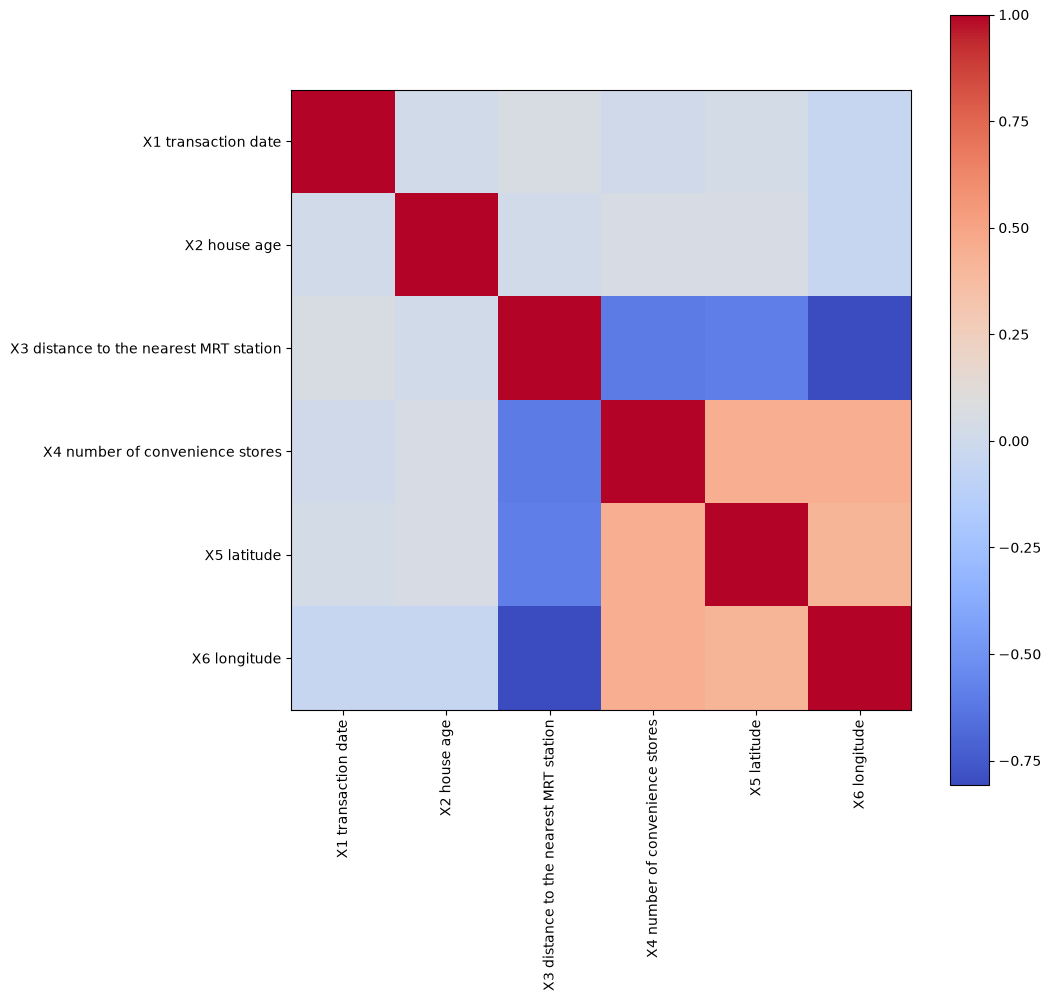

In [141]:
corr = X.corr()


plt.figure(figsize=(10, 10))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

X4, X5 and X6 positively correlate with eachother and X3 negatively correlates with X4, X5 abd X6. It might be that my first assumption of longitude not mattering might be wrong as the coeficcents are probably a bit skewed as longitde correlates with so many things.

In [142]:
#Logistic regression evaluation
print("Coefficients: ",log_model.coef_)
print("Intercept: ", log_model.intercept_)

log_preds = log_model.predict(X_test)
cm = confusion_matrix(log_y_test, log_preds)
accuracy = accuracy_score(log_y_test, log_preds)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

Coefficients:  [[ 0.25260606 -0.55226733 -2.4289223   0.56142519  0.81941172  0.06234993]]
Intercept:  [-0.53710247]
Accuracy: 0.81
Confusion Matrix:
 [[43 20]
 [ 4 58]]
